# 🛢 Understanding Natural Gas Price Dynamics
> ### ***The Influence of Storage Levels, Abnormal Inventories, and Momentum Effects***

# 📊 Project Overview

This project investigates how U.S. natural gas storage dynamics influence price movements, using weekly data from the U.S. Energy Information Administration (EIA).Rather than treating prices as purely market-driven, this analysis combines fundamental supply signals (storage injections/withdrawals), seasonal context (storage relative to historical norms),and market dynamics (lagged effects and persistence) to build a structured understanding of what actually drives short-term price changes.

## 🎯 Objective

The goal is to answer three key questions:

1. To what extent do changes in storage levels influence  price movements?
2. Do deviations from seasonal storage norms provide additional predictive insight into price behavior?
3. What is the relative importance of fundamental signals versus momentum in explaining price behavior?

## 🧠 Methodology

The analysis follows a time-series econometric approach:

- Constructed log returns to model price changes
- Engineered lagged variables to reflect delayed market reactions
- Built a seasonal Z-score to normalize storage levels
- Introduced interaction effects to test non-linear dynamics
- Applied Newey-West (HAC) corrections to address autocorrelation

Two model frameworks were developed:
- Economic Model → focuses on storage fundamentals
- Predictive Model → incorporates price momentum

## Fetch Data
_Fetching data from eia.gov API_

In [1]:
import pandas as pd
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
#Function fetching data from EIA API
def fetch_eia_data(base_url, eia_apikey, endpoint, params_dict):
    
    params_dict['api_key'] = eia_apikey
    
    response = requests.get(f"{base_url}{endpoint}", params=params_dict)
    data = response.json()
    
    if 'response' not in data:
        print(f"Error: {data.get('error', 'Unknown error')}")
        return None
    
    total_records = data.get('response', {}).get('total', 0)
    data_array = data.get('response', {}).get('data', [])
    
    if not data_array:
        print('No data returned')
        return None
    
    df = pd.json_normalize(data_array)
    
    print(f"Retrieved {len(data_array)} of {total_records} records from {endpoint}")
    print('='*75)
    
    return df

In [4]:
# Fetching data
base_url = 'https://api.eia.gov/v2'

# 1. Natural gas price
price_params = {
    'frequency': 'weekly',
    'facets[series][]': 'RNGWHHD',
    'data[0]': 'value',
    'start': '2010-01',
    'end': '2024-12',
}

price_df = fetch_eia_data(base_url, eia_apikey, '/natural-gas/pri/fut/data', price_params)

# 2. Natural gas storage
storage_params = {
    'frequency': 'weekly',
    'facets[series][]': 'NW2_EPG0_SWO_R48_BCF',
    'data[0]': 'value',
    'start': '2005-01',
    'end': '2024-12',
}

storage_df = fetch_eia_data(base_url, eia_apikey, '/natural-gas/stor/wkly/data', storage_params)


Retrieved 779 of 779 records from /natural-gas/pri/fut/data
Retrieved 779 of 779 records from /natural-gas/stor/wkly/data


In [5]:
# Rename columns
storage_df = storage_df.rename(columns={'value': 'Natural Gas Working Underground Storage (BCF)'})
price_df = price_df.rename(columns={'value': 'Natural Gas price($/MMBTU)'})

# Merge df
merged_df = pd.merge(price_df, storage_df, on='period')

df = merged_df[['period',
                     'Natural Gas Working Underground Storage (BCF)',
                     'Natural Gas price($/MMBTU)']]

df.head()

,period,Natural Gas Working Underground Storage (BCF),Natural Gas price($/MMBTU)
0,2010-01-01,3117,5.88
1,2010-01-08,2850,6.56
2,2010-01-15,2607,5.68
3,2010-01-22,2521,5.56
4,2010-01-29,2406,5.47


In [6]:
df = df.copy()

columns = ['Natural Gas Working Underground Storage (BCF)',
            'Natural Gas price($/MMBTU)']
df["period"] = pd.to_datetime(df["period"])

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df['week'] = df['period'].dt.isocalendar().week
df['year'] = df['period'].dt.isocalendar().year
df = df.sort_values(['week', 'year'])

## Feature Engineering

In [7]:
df = df[df['week'] != 53]

df['Storage 5yr_Avg'] = (
    df.groupby('week')['Natural Gas Working Underground Storage (BCF)']
      .transform(lambda x: x.rolling(5, min_periods=5).mean())
)

In [8]:
df_model = df.copy()

#Created needed columns
df_model['Storage Deviation'] = df_model['Natural Gas Working Underground Storage (BCF)'] - df_model['Storage 5yr_Avg']
df_model['Price Change'] = df['Natural Gas price($/MMBTU)'].diff()
df_model['Storage Change'] = df['Natural Gas Working Underground Storage (BCF)'].diff()
df_model['storage_dev_lag1'] = df_model['Storage Deviation'].shift(1)
df_model['price_lag1'] = df_model['Natural Gas price($/MMBTU)'].shift(1)
df_model['Price Return'] = np.log(df['Natural Gas price($/MMBTU)'] / df['Natural Gas price($/MMBTU)'].shift(1))
df_model['Price Return %'] = df_model['Price Return'] * 100
df_model['5yr_std'] = df_model.groupby('week')['Natural Gas Working Underground Storage (BCF)'].transform('std')
df_model['Storage Zscore'] = (df['Natural Gas Working Underground Storage (BCF)'] - df['Storage 5yr_Avg']) / df_model['5yr_std']
df_model['storage_change_lag1'] = df_model['Storage Change'].shift(1)
df_model['storage_zscore_lag1'] = df_model['Storage Zscore'].shift(1)
df_model['price_return_lag1'] = df_model['Price Return'].shift(1)
df_model['interaction'] = df_model['storage_change_lag1'] * df_model['storage_zscore_lag1']

df_model = df_model[df_model['year'] >= 2015]
df_model = df_model.sort_values('period')

In [9]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 516 entries, 261 to 778
Data columns (total 19 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   period                                         516 non-null    datetime64[ns]
 1   Natural Gas Working Underground Storage (BCF)  516 non-null    int64         
 2   Natural Gas price($/MMBTU)                     516 non-null    float64       
 3   week                                           516 non-null    UInt32        
 4   year                                           516 non-null    UInt32        
 5   Storage 5yr_Avg                                516 non-null    float64       
 6   Storage Deviation                              516 non-null    float64       
 7   Price Change                                   516 non-null    float64       
 8   Storage Change                                 516 non-null    

# 📊 Exploratory Data Analysis: Storage and Price Relationships

Before estimating the regression models, it is useful to visually examine the relationship between storage variables and price changes. The following  plots provide initial insight into how different measures of storage relate to market behavior

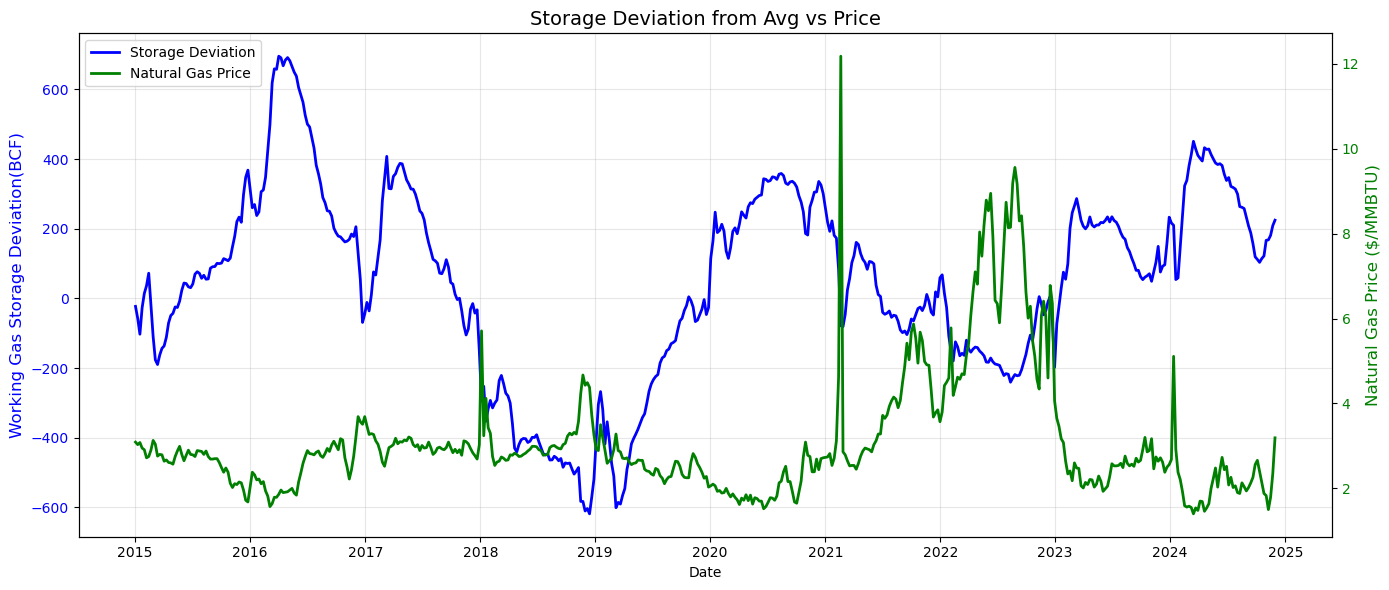

In [10]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Left axis: Storage Deviation 
ax1.plot(df_model["period"], df_model['Storage Deviation'], 
         'b-', label='Storage Deviation', linewidth=2)  
ax1.set_xlabel('Date')
ax1.set_ylabel('Working Gas Storage Deviation(BCF)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

# Right axis: Natural Gas Price 
ax2 = ax1.twinx()
ax2.plot(df_model['period'], df_model['Natural Gas price($/MMBTU)'], 
         'g-', label='Natural Gas Price', linewidth=2)  
ax2.set_ylabel('Natural Gas Price ($/MMBTU)', color='g', fontsize=12)  
ax2.tick_params(axis='y', labelcolor='g')  

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Storage Deviation from Avg vs Price', fontsize=14)
plt.tight_layout()
plt.show()

### 💡Insight
>    Storage deviations measure whether inventories are above or below their typical seasonal levels, providing a clearer indication of market tightness than absolute storage volumes. Overall, the **graph suggests a negative relationship between storage deviations and natural gas prices**: periods of below-average storage generally coincide with higher prices, while above-average storage is associated with lower and more stable prices.

### ⚠️ Important Caveat

> **The storage–price relationship is not absolute.** While below-average storage generally supports higher prices, major external shocks can dominate market fundamentals. During **2021–2022**, rising LNG exports, post-pandemic demand recovery, extreme weather, and geopolitical events(eg.Russia–Ukraine conflict) significantly increased market tightness and uncertainty, causing prices to rise far beyond what storage deficits alone would predict.


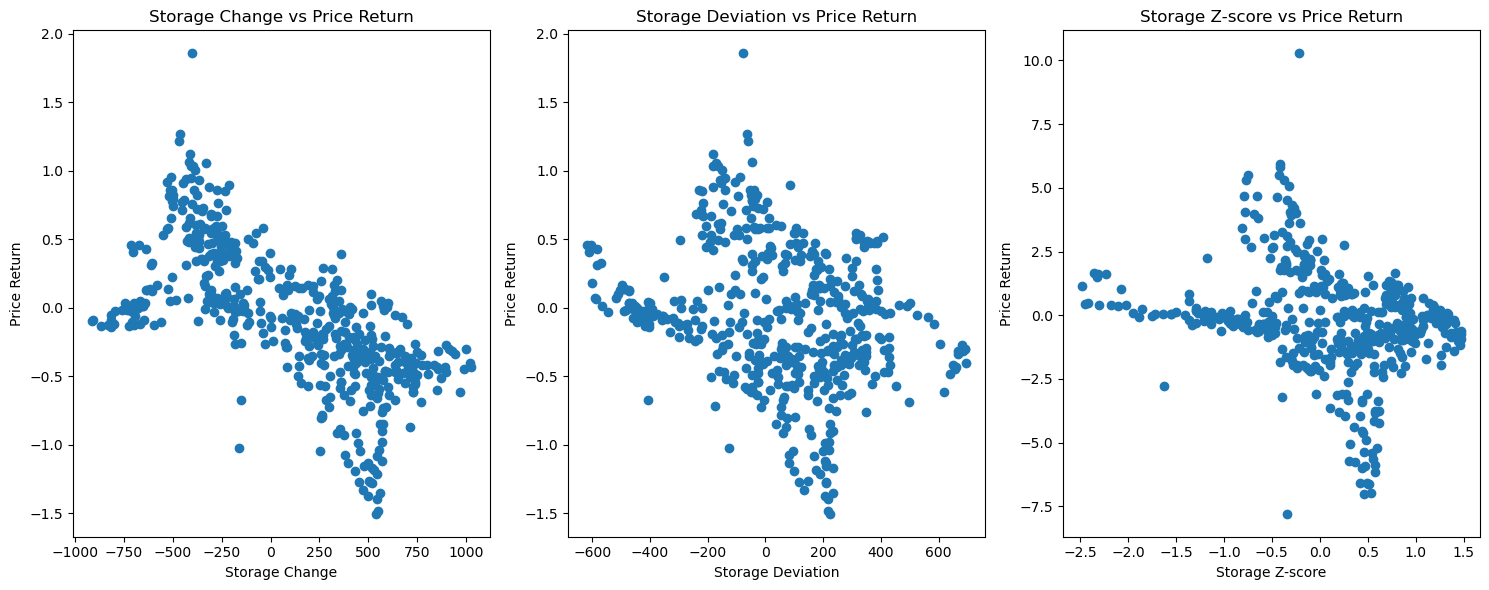

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))

#Storage Change vs Price Return
ax1.scatter(
    df_model['Storage Change'], 
    df_model['Price Return']
)
ax1.set_xlabel('Storage Change')
ax1.set_ylabel('Price Return')
ax1.set_title('Storage Change vs Price Return')

#Storage Deviation vs Price Return
ax2.scatter(
    df_model['Storage Deviation'], 
    df_model['Price Return']  
)
ax2.set_xlabel('Storage Deviation')
ax2.set_ylabel('Price Return')
ax2.set_title('Storage Deviation vs Price Return')  

#Storage_z vs Price Return
ax3.scatter(
    df_model['Storage Zscore'],  
    df_model['Price Change'] 
)
ax3.set_xlabel('Storage Z-score')
ax3.set_ylabel('Price Return')
ax3.set_title('Storage Z-score vs Price Return')

plt.tight_layout()
plt.show()

### 🔍 Key Observations

- **Storage Change vs Price Return**  
  The relationship between storage changes and price returns is clearly negative and approximately linear. Periods of inventory builds are associated with declining prices, while inventory drawdowns correspond to price increases. The relatively tight clustering around a downward slope suggests that short-term supply shocks are a key driver of price movements.

- **Storage Deviation vs Price Return**  
  While storage deviations from seasonal norms exhibit a negative relationship with price returns, the pattern is more dispersed compared to raw storage changes. This suggests that while deviations capture longer-term imbalances, they are less effective at explaining short-term price movements.

- **Storage Z-score vs Price Return**  
  The standardized storage measure (z-score) shows a weaker and less visually intuitive relationship with price returns. Although extreme values correspond to larger price movements, the overall pattern is less clearly defined, suggesting that normalization may obscure economically meaningful variation in storage levels.

### 💡Insight

>Overall, the visual evidence suggests a **consistent negative relationship between storage measures and price returns**, with raw storage changes providing the clearest signal. However, the presence of dispersion across all plots indicates that storage alone does not fully explain price movements. To formally quantify these relationships and assess statistical significance, regression models are estimated in the following section.

---

# 💰Economic Model: Storage-Driven Price Dynamics

The first model focuses on understanding how **physical market fundamentals** influence natural gas price movements.

In particular, this specification examines whether changes in storage levels and deviations from seasonal norms can explain subsequent price returns. Since energy markets often react with a delay, all explanatory variables are **lagged by one period** to reflect realistic market behavior.

The model includes:

- **Storage Change (lagged)** → captures immediate supply shocks  
- **Storage Z-score (lagged)** → measures how unusual current storage levels are relative to seasonal patterns  
- **Interaction Term** → tests whether the impact of storage changes depends on the overall storage environment  

To ensure reliable statistical inference, the model is estimated using **Newey-West (HAC) standard errors**, which correct for potential autocorrelation and heteroskedasticity in time-series data.

This framework is primarily **explanatory**, aiming to quantify the role of storage fundamentals in driving price movements.

In [12]:
df_model2 = df_model.dropna()
X = df_model2[['storage_change_lag1',
               'storage_zscore_lag1',
               'interaction']]

X = sm.add_constant(X)
y = df_model2['Price Return']

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Price Return   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     93.38
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           3.25e-48
Time:                        21:25:30   Log-Likelihood:                -269.66
No. Observations:                 516   AIC:                             547.3
Df Residuals:                     512   BIC:                             564.3
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.1023    

### 📝 Results Interpretation

The model explains approximately **35.6% of the variation in price returns**, indicating that storage fundamentals play a meaningful role in price formation.

- **Storage Z-score (lagged)** has a **large positive coefficient (0.3980) and is highly significant (p < 0.001)**.  
  → This suggests that when storage levels are unusually high relative to seasonal norms, prices tend to increase in the following period.  
  → Economically, this reflects **expectations of future rebalancing or mean reversion**.

- **Storage Change (lagged)** has a **small negative coefficient (-0.0001) and is only marginally significant (p ≈ 0.08)**.  
  → This indicates weaker evidence that short-term supply shocks alone directly drive prices once broader storage context is considered.

- The **interaction term** is **positive (0.0002) and highly significant (p < 0.001)**.  
  → This implies that the impact of storage changes depends on the level of storage.  
  → In other words, **supply shocks matter more when storage is already elevated**, highlighting non-linear market behavior.

Overall, the results suggest that **relative storage positioning is more important than absolute changes**, and that price responses are **state-dependent rather than purely linear**.

---

## 🔄 From Fundamentals to Market Dynamics

While the economic model demonstrates that storage fundamentals significantly influence price movements, it does not fully capture short-term price behavior.

Financial time series, particularly in commodity markets, often exhibit **mean reversion and persistence**, where past price movements influence future returns.

To account for this, we extend the analysis by incorporating lagged price returns into a predictive model. This allows us to evaluate whether market dynamics provide additional explanatory power beyond storage fundamentals.

---

# 🤖 Model Incorporating Market Dynamics

While the economic model emphasizes fundamentals, financial time series are often influenced by **momentum and persistence** in price movements.

To account for this, a second model is constructed that incorporates **lagged price returns** alongside storage variables. This allows us to evaluate whether past price behavior provides additional predictive power beyond fundamental factors.

The model includes:

- **Lagged Price Return** → captures short-term momentum effects  
- **Storage Change (lagged)** → retains supply-side information  
- **Storage Z-score (lagged)** → retains seasonal positioning  

Unlike the previous model, this specification is more **prediction-oriented**, aiming to assess how well future price movements can be explained when both **fundamentals and market dynamics** are considered.

Comparing this model to the economic model provides insight into the relative importance of:
- Structural supply-demand factors  
- Behavioral and market-driven effects  

This distinction is central to understanding how energy markets operate in practice.

In [13]:
X = df_model[['price_lag1',
              'storage_change_lag1',
              'storage_zscore_lag1']]

X = sm.add_constant(X)
y = df_model['Price Return']

model2 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':1})
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           Price Return   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     167.8
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           9.35e-76
Time:                        21:25:30   Log-Likelihood:                -137.35
No. Observations:                 516   AIC:                             282.7
Df Residuals:                     512   BIC:                             299.7
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.6899    

### 📝 Results Interpretation

After applying HAC standard errors, the model explains approximately **61.4% of the variation in price returns**, representing a substantial improvement over the economic model.

- **Lagged Price Return** has a **negative coefficient (-0.2195) and is highly significant (p < 0.001)**.  
  → This indicates strong **mean-reverting behavior**, where price increases are typically followed by partial reversals in the next period.

- **Storage Change (lagged)** remains **negative (-0.0004) and highly significant (p < 0.001)**.  
  → This confirms that **supply shocks continue to impact prices**, even after accounting for price dynamics.

- **Storage Z-score (lagged)** is **positive (0.3157) and highly significant (p < 0.001)**.  
  → This shows that **relative storage levels retain predictive power**, reinforcing the importance of seasonal context.

Overall, the results indicate that **both market dynamics and storage fundamentals jointly drive price movements**. While lagged price behavior captures short-term adjustments, storage variables continue to provide economically meaningful signals.

---

# 🏆 Conclusion

Natural gas prices are influenced by both storage fundamentals and market dynamics, but their relative importance varies across market conditions and time horizons. This analysis examined three key questions: whether storage levels influence price movements, whether deviations from seasonal norms provide additional insight, and how fundamentals compare with momentum in explaining price behavior.

The results show that **storage conditions play a meaningful role in price formation**, although their influence is conditional rather than absolute. Changes in storage levels affect price behavior in a statistically significant manner, confirming that physical supply conditions contribute to market outcomes. However, similar storage environments can produce different price responses, indicating that storage alone is insufficient to explain short-term price fluctuations.

The analysis also demonstrates that **storage deviations from seasonal norms provide valuable information beyond absolute inventory levels.** Storage Z-scores remain highly significant across model specifications, suggesting that inventory conditions relative to historical expectations are more informative than raw storage levels alone. By identifying periods of unusual surplus or deficit, these measures help capture market conditions that are associated with distinct price responses.

While storage fundamentals explain a meaningful portion of price variation, they do not fully account for short-term price behavior. **The fundamentals-only model explains approximately 36% of variation in price returns**, indicating that a substantial share of market movements remains unexplained. **When lagged price returns are introduced, explanatory power increases to more than 61%**, revealing strong mean-reverting behavior and highlighting the importance of internal market dynamics. Importantly, **storage variables remain statistically significant even after controlling for momentum effects**, confirming that fundamentals continue to influence prices despite the presence of strong market feedback mechanisms.


## 🔑 Key Findings

Natural gas prices are best understood as the product of a dual-engine mechanism:

- **Fundamentals:** Storage levels and deviations from seasonal norms establish the underlying supply environment and shape market expectations.

- **Market Dynamics:** Mean reversion and price feedback mechanisms drive short-term adjustments and account for a substantial share of price variation.

These forces operate jointly rather than independently. Fundamentals provide the structural foundation for price formation, while market dynamics determine how prices adjust over time. Price behavior is therefore best understood as the outcome of continuous interaction between real-world supply conditions and self-correcting market processes, rather than the result of a single dominant driver.

## 🎯 Implications for Forecasting

Storage conditions matter, and inventories that deviate from seasonal norms provide valuable signals about market tightness and supply conditions. However, **short-term price movements are explained more strongly by market dynamics than by storage fundamentals alone.** Effective analysis and forecasting therefore require combining fundamental indicators with momentum-based signals rather than relying on either in isolation.

---

# ⚠️ Limitations
- The model focuses mainly on storage variables and may omit other key drivers such as demand, weather, and macroeconomic factors.
- Storage measures are proxies, which may not fully capture real supply-demand dynamics.
- The analysis assumes linear relationships, potentially missing nonlinear effects during extreme conditions.
- Evidence of autocorrelation and multicollinearity may affect coefficient reliability.
- The model is better suited for explaining short-term price behavior and may have limited ability to capture longer-term structural trends or regime shifts.

# 🚀 Recommendations
- Include additional variables (e.g., demand, weather, production) to improve model accuracy.
- Explore nonlinear or machine learning models to capture complex relationships.
- Apply time-series methods to distinguish short-term vs long-term effects.
- Test results across different market conditions to ensure robustness.